In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.autograd as autograd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Το μοντέλο θα τρέξει σε: {device}")

BATCH_SIZE = 64

# Κανονικοποίηση στο [-1, 1] για Tanh στο GAN
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Κατέβασμα δεδομένων Fashion-MNIST...")
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

Το μοντέλο θα τρέξει σε: cuda
Κατέβασμα δεδομένων Fashion-MNIST...


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.98MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.8MB/s]


In [ ]:
def get_task_data(dataset, classes):
    targets = np.array(dataset.targets)
    mask = np.isin(targets, classes)
    indices = np.where(mask)[0]
    return Subset(dataset, indices)

tasks = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
train_loaders, test_loaders = [], []

for task_classes in tasks:
    train_loaders.append(DataLoader(get_task_data(train_dataset, task_classes), batch_size=BATCH_SIZE, shuffle=True))
    test_loaders.append(DataLoader(get_task_data(test_dataset, task_classes), batch_size=BATCH_SIZE, shuffle=False))

print("Το Split Fashion-MNIST είναι έτοιμο!")

Το Split Fashion-MNIST είναι έτοιμο!


In [ ]:
# --- 1. ΠΑΝΙΣΧΥΡΟΣ RESNET-STYLE CLASSIFIER ---
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class StrongClassifier(nn.Module):
    def __init__(self):
        super(StrongClassifier, self).__init__()
        self.prep = nn.Sequential(nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU())
        self.layer1 = ResidualBlock(32, 64, stride=2)  # 14x14
        self.layer2 = ResidualBlock(64, 128, stride=2) # 7x7
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128 * 7 * 7, 10)

    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)

# --- 2. AC-WGAN-GP (GENERATOR & CRITIC) ---
LATENT_DIM = 100

class ACGenerator(nn.Module):
    def __init__(self):
        super(ACGenerator, self).__init__()
        self.label_emb = nn.Embedding(10, 10)
        self.l1 = nn.Sequential(nn.Linear(LATENT_DIM + 10, 256 * 7 * 7))
        self.conv = nn.Sequential(
            nn.InstanceNorm2d(256),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), nn.InstanceNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), nn.InstanceNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        c = self.label_emb(labels)
        x = torch.cat([noise, c], dim=-1)
        out = self.l1(x).view(x.size(0), 256, 7, 7)
        return self.conv(out)

class ACCritic(nn.Module):
    def __init__(self):
        super(ACCritic, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.LeakyReLU(0.2)
        )
        # 2 Έξοδοι: Real/Fake (WGAN) και Ταξινόμηση Κλάσης (AC-GAN)
        self.adv_layer = nn.Linear(256 * 7 * 7, 1)
        self.aux_layer = nn.Linear(256 * 7 * 7, 10)

    def forward(self, img):
        out = self.conv(img).view(img.size(0), -1)
        return self.adv_layer(out), self.aux_layer(out)

def compute_gradient_penalty(critic, real, fake):
    alpha = torch.rand(real.size(0), 1, 1, 1).to(device)
    interpolates = (alpha * real + ((1 - alpha) * fake)).requires_grad_(True)
    d_interpolates, _ = critic(interpolates)
    fake_labels = torch.ones(real.size(0), 1).to(device)
    gradients = autograd.grad(outputs=d_interpolates, inputs=interpolates, grad_outputs=fake_labels,
                              create_graph=True, retain_graph=True, only_inputs=True)[0]
    return ((gradients.view(gradients.size(0), -1).norm(2, dim=1) - 1) ** 2).mean()

# --- 3. ΣΥΝΑΡΤΗΣΕΙΣ ΑΞΙΟΛΟΓΗΣΗΣ & ΕΙΚΟΝΩΝ ---
criterion_class = nn.CrossEntropyLoss()

def evaluate_model(model, test_loaders, current_task_idx):
    model.eval()
    accs = []
    with torch.no_grad():
        for i in range(current_task_idx + 1):
            correct, total = 0, 0
            for data, target in test_loaders[i]:
                data, target = data.to(device), target.to(device)
                _, pred = torch.max(model(data), 1)
                total += target.size(0); correct += (pred == target).sum().item()
            accs.append(100 * correct / total)
    return accs

def calculate_forgetting(acc_matrix):
    f = []
    for j in range(4):
        max_past = max([acc_matrix[i][j] for i in range(j, 4)])
        f.append(max_past - acc_matrix[4][j])
    return np.mean(f) if f else 0

def plot_generated_images(generator, current_classes):
    generator.eval()
    num_classes = len(current_classes)
    fig, axes = plt.subplots(1, num_classes, figsize=(num_classes * 1.5, 2))
    with torch.no_grad():
        for i, cls in enumerate(current_classes):
            z = torch.randn(1, LATENT_DIM).to(device)
            y = torch.tensor([cls]).to(device)
            gen_img = generator(z, y).cpu().squeeze()
            gen_img = gen_img * 0.5 + 0.5 # De-normalize

            ax = axes[i] if num_classes > 1 else axes
            ax.imshow(gen_img, cmap='gray')
            ax.set_title(f"Class {cls}", fontsize=10)
            ax.axis('off')
    plt.show()

In [ ]:
print("\n=== ΕΚΤΕΛΕΣΗ 1/3: NAIVE APPROACH ===")
naive_classifier = StrongClassifier().to(device)
opt_naive = optim.Adam(naive_classifier.parameters(), lr=0.001)
naive_acc_matrix = []

EPOCHS_NAIVE = 5

for task_idx, train_loader in enumerate(train_loaders):
    print(f"---> Εκπαίδευση NAIVE στο Task {task_idx + 1}...")
    naive_classifier.train()

    for epoch in range(EPOCHS_NAIVE):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            opt_naive.zero_grad()
            loss = criterion_class(naive_classifier(data), target)
            loss.backward()
            opt_naive.step()

    accs = evaluate_model(naive_classifier, test_loaders, task_idx)
    naive_acc_matrix.append(accs)
    print(f"Αποτελέσματα: {[round(a, 2) for a in accs]}")


=== ΕΚΤΕΛΕΣΗ 1/3: NAIVE APPROACH ===
---> Εκπαίδευση NAIVE στο Task 1...
Αποτελέσματα: [99.6]
---> Εκπαίδευση NAIVE στο Task 2...
Αποτελέσματα: [0.0, 97.4]
---> Εκπαίδευση NAIVE στο Task 3...
Αποτελέσματα: [0.0, 0.0, 99.95]
---> Εκπαίδευση NAIVE στο Task 4...
Αποτελέσματα: [0.0, 0.0, 0.0, 100.0]
---> Εκπαίδευση NAIVE στο Task 5...
Αποτελέσματα: [0.0, 0.0, 0.0, 0.0, 99.8]


In [ ]:
print("\n=== ΕΚΤΕΛΕΣΗ 2/3: MEMORY BUFFER ===")
buffer_classifier = StrongClassifier().to(device)
opt_buffer = optim.Adam(buffer_classifier.parameters(), lr=0.001)
buffer_acc_matrix = []
memory_data, memory_targets = [], []

SAMPLES_PER_TASK = 1000

for task_idx, train_loader in enumerate(train_loaders):
    print(f"---> Εκπαίδευση BUFFER στο Task {task_idx + 1}...")
    buffer_classifier.train()

    task_d, task_t = [], []
    for d, t in train_loader:
        task_d.append(d)
        task_t.append(t)
    memory_data.append(torch.cat(task_d)[:SAMPLES_PER_TASK])
    memory_targets.append(torch.cat(task_t)[:SAMPLES_PER_TASK])

    for epoch in range(EPOCHS_NAIVE):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            if task_idx > 0:
                old_d = torch.cat(memory_data[:task_idx]).to(device)
                old_t = torch.cat(memory_targets[:task_idx]).to(device)
                idx = torch.randperm(len(old_d))[:len(data)]
                data = torch.cat([data, old_d[idx]])
                target = torch.cat([target, old_t[idx]])

            opt_buffer.zero_grad()
            loss = criterion_class(buffer_classifier(data), target)
            loss.backward()
            opt_buffer.step()

    accs = evaluate_model(buffer_classifier, test_loaders, task_idx)
    buffer_acc_matrix.append(accs)
    print(f"Αποτελέσματα: {[round(a, 2) for a in accs]}")


=== ΕΚΤΕΛΕΣΗ 2/3: MEMORY BUFFER ===
---> Εκπαίδευση BUFFER στο Task 1...
Αποτελέσματα: [99.55]
---> Εκπαίδευση BUFFER στο Task 2...
Αποτελέσματα: [89.15, 97.25]
---> Εκπαίδευση BUFFER στο Task 3...
Αποτελέσματα: [92.15, 81.25, 98.25]
---> Εκπαίδευση BUFFER στο Task 4...
Αποτελέσματα: [78.8, 76.3, 80.5, 95.1]
---> Εκπαίδευση BUFFER στο Task 5...
Αποτελέσματα: [86.25, 80.35, 85.15, 81.6, 98.6]



=== ΕΚΤΕΛΕΣΗ 3/3: AC-WGAN-GP GENERATIVE REPLAY (v2 — ΔΙΟΡΘΩΜΕΝΟ) ===

---> Εκπαίδευση AC-GAN στο Task 1...

[Δείγματα ρούχων από το AC-GAN:]


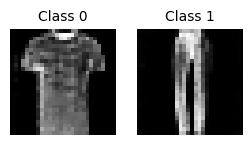

Αποτελέσματα μετά το Task 1: [99.6]

---> Εκπαίδευση AC-GAN στο Task 2...

[Δείγματα ρούχων από το AC-GAN:]


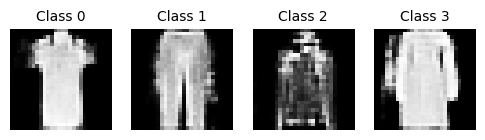

Αποτελέσματα μετά το Task 2: [79.2, 98.25]

---> Εκπαίδευση AC-GAN στο Task 3...

[Δείγματα ρούχων από το AC-GAN:]


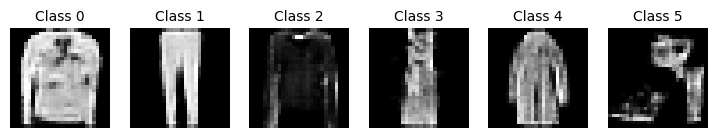

Αποτελέσματα μετά το Task 3: [72.95, 54.2, 99.65]

---> Εκπαίδευση AC-GAN στο Task 4...

[Δείγματα ρούχων από το AC-GAN:]


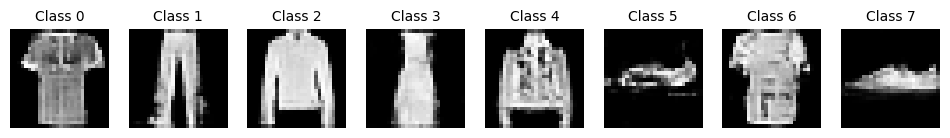

Αποτελέσματα μετά το Task 4: [48.5, 25.05, 46.9, 99.4]

---> Εκπαίδευση AC-GAN στο Task 5...

[Δείγματα ρούχων από το AC-GAN:]


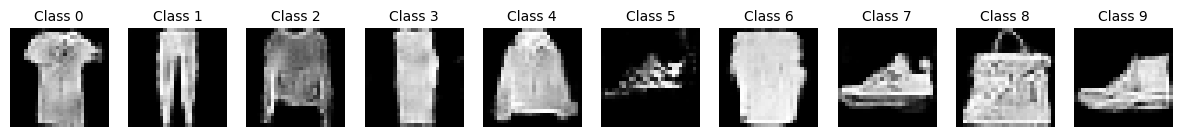

Αποτελέσματα μετά το Task 5: [65.45, 52.65, 68.2, 78.7, 99.25]


In [ ]:
print("\n=== ΕΚΤΕΛΕΣΗ 3/3: AC-WGAN-GP GENERATIVE REPLAY (v2 — ΔΙΟΡΘΩΜΕΝΟ) ===")

# ═══════════════════════════════════════════════════════════════════════════
#  ΣΥΝΟΨΗ ΔΙΟΡΘΩΣΕΩΝ
# ───────────────────────────────────────────────────────────────────────────
#  ΠΡΟΒΛΗΜΑ Α: Task 4 = 0.0%
#    Αιτία: fake_prev_target = y_prev (labels που ΖΗΤΗΘΗΚΑΝ από τον Generator,
#    όχι αυτά που ΠΑΡΑΧΘΗΚΑΝ). Αν ο Generator παρεκκλίνει για κλάσεις που
#    είδε μόνο 1 round πριν, ο Classifier μαθαίνει λάθος image→label pairs.
#
#  FIX 1 — Pseudo-labels μέσω prev_classifier  [κύριο fix]
#    Αντί y_prev, περνάμε τις generated εικόνες από τον frozen classifier
#    → αξιόπιστα labels ανεξάρτητα από ό,τι "νόμιζε" ο Generator.
#
#  FIX 2 — REPLAY_RATIO σταθερό (αντί balanced-per-class)
#    Παλιά λογική: n_per_class = bs // len(past_classes)
#      → στο Task 5: 64//8 = 8 ανά κλάση = 64 fake = 50% του batch
#      → το νέο task υποεκπροσωπείται → REVERSE FORGETTING
#    Νέα λογική: n_fake_total = int(bs * REPLAY_RATIO)  [π.χ. 30%]
#      → πάντα ~19 fake ανεξάρτητα από πόσα past tasks υπάρχουν
#      → το μοντέλο αφιερώνει 70% στο νέο task, 30% στη μνήμη
#
#  FIX 3 — LAMBDA_AUX: 1.0 → 2.0
#    Ενισχύουμε το auxiliary classification signal στον Critic/Generator
#    ώστε ο Generator να παράγει class-faithful εικόνες πιο αξιόπιστα.
#
#  FIX 4 — Confidence threshold για pseudo-labels
#    Samples με softmax confidence < CONF_THRESHOLD αποκλείονται.
#    Λιγότερα αλλά σωστά δεδομένα > noisy pairs που μπερδεύουν.
# ═══════════════════════════════════════════════════════════════════════════

gr_classifier = StrongClassifier().to(device)
gr_G = ACGenerator().to(device)
gr_C = ACCritic().to(device)

opt_class = optim.Adam(gr_classifier.parameters(), lr=0.001)
opt_G     = optim.Adam(gr_G.parameters(), lr=0.0001, betas=(0.0, 0.9))
opt_C     = optim.Adam(gr_C.parameters(), lr=0.0001, betas=(0.0, 0.9))

prev_classifier, prev_G = None, None
gr_acc_matrix = []

EPOCHS_GR      = 15
LAMBDA_GP      = 10
LAMBDA_AUX     = 2.0   # FIX 3: 1.0 → 2.0
REPLAY_RATIO   = 0.30  # FIX 2: fake data = σταθερό 30% του real batch
CONF_THRESHOLD = 0.70  # FIX 4: min confidence για pseudo-labels


def generate_replay_batch(prev_G, prev_classifier, past_classes, n_fake_total, conf_threshold=0.70):
    """
    FIX 1 + FIX 2 + FIX 4: Παράγει replay data με pseudo-labels.

    - Χρησιμοποιεί REPLAY_RATIO ώστε τα fake data να είναι πάντα σταθερό
      ποσοστό του batch (FIX 2) — αποτρέπει το Reverse Forgetting.
    - Τα labels προέρχονται από τον frozen prev_classifier (FIX 1)
      αντί από τα requested labels του Generator.
    - Samples με χαμηλή confidence αποκλείονται (FIX 4).
    - Balanced ανά κλάση: n_per_class = n_fake_total // len(past_classes).
    """
    prev_G.eval()
    prev_classifier.eval()
    all_imgs, all_labels = [], []

    # Πόσα samples ανά κλάση (balanced)
    n_per_class = max(n_fake_total // len(past_classes), 2)

    with torch.no_grad():
        for cls in past_classes:
            # Oversample για να αντισταθμίσουμε τα rejected samples
            oversample = max(int(n_per_class * 2), n_per_class + 16)
            z           = torch.randn(oversample, LATENT_DIM).to(device)
            y_req       = torch.full((oversample,), cls, dtype=torch.long).to(device)
            fake_imgs   = prev_G(z, y_req)

            # FIX 1: Pseudo-labels από τον frozen classifier
            logits       = prev_classifier(fake_imgs)
            probs        = torch.softmax(logits, dim=1)
            conf, pseudo = probs.max(dim=1)

            # FIX 4: Κρατάμε μόνο confident predictions
            mask = conf >= conf_threshold
            if mask.sum() < 2:
                # Fallback: κράτα τα top-k ακόμα και αν δεν φτάνουν το threshold
                _, topk_idx = conf.topk(min(n_per_class, oversample))
                mask = torch.zeros(oversample, dtype=torch.bool, device=device)
                mask[topk_idx] = True

            all_imgs.append(fake_imgs[mask][:n_per_class])
            all_labels.append(pseudo[mask][:n_per_class])

    return torch.cat(all_imgs).detach(), torch.cat(all_labels)


for task_idx, train_loader in enumerate(train_loaders):
    print(f"\n---> Εκπαίδευση AC-GAN στο Task {task_idx + 1}...")
    past_classes     = [c for past_task in tasks[:task_idx] for c in past_task]
    all_seen_classes = past_classes + tasks[task_idx]

    for epoch in range(EPOCHS_GR):
        gr_classifier.train(); gr_G.train(); gr_C.train()

        for real_data, real_target in train_loader:
            real_data, real_target = real_data.to(device), real_target.to(device)
            bs = real_data.size(0)

            # ── FIX 1+2+4: Replay με σταθερό ratio + pseudo-labels ──────
            if prev_G is not None and len(past_classes) > 0:
                # FIX 2: σταθερό 30% — ανεξάρτητο από τον αριθμό past tasks
                n_fake_total = max(int(bs * REPLAY_RATIO), len(past_classes))
                fake_imgs, fake_labels = generate_replay_batch(
                    prev_G, prev_classifier, past_classes,
                    n_fake_total=n_fake_total,
                    conf_threshold=CONF_THRESHOLD
                )
                c_data   = torch.cat([real_data, fake_imgs])
                c_target = torch.cat([real_target, fake_labels])
            else:
                c_data, c_target = real_data, real_target

            total_bs = c_data.size(0)

            # 1. Εκπαίδευση Classifier
            opt_class.zero_grad()
            loss_class = criterion_class(gr_classifier(c_data), c_target)
            loss_class.backward()
            opt_class.step()

            # 2. Εκπαίδευση AC-WGAN Critic (5 steps ανά generator step)
            for _ in range(5):
                opt_C.zero_grad()
                z_curr    = torch.randn(total_bs, LATENT_DIM).to(device)
                fake_imgs_c = gr_G(z_curr, c_target)

                real_val, real_aux = gr_C(c_data)
                fake_val, fake_aux = gr_C(fake_imgs_c.detach())

                gp = compute_gradient_penalty(gr_C, c_data, fake_imgs_c.detach())

                # FIX 3: LAMBDA_AUX = 2.0
                loss_adv = -torch.mean(real_val) + torch.mean(fake_val) + LAMBDA_GP * gp
                loss_aux = criterion_class(real_aux, c_target) + criterion_class(fake_aux, c_target)
                loss_C   = loss_adv + LAMBDA_AUX * loss_aux
                loss_C.backward()
                opt_C.step()

            # 3. Εκπαίδευση AC-WGAN Generator
            opt_G.zero_grad()
            z_curr      = torch.randn(total_bs, LATENT_DIM).to(device)
            fake_imgs_g = gr_G(z_curr, c_target)
            fake_val, fake_aux = gr_C(fake_imgs_g)

            # FIX 3: LAMBDA_AUX = 2.0
            loss_G = -torch.mean(fake_val) + LAMBDA_AUX * criterion_class(fake_aux, c_target)
            loss_G.backward()
            opt_G.step()

    print("\n[Δείγματα ρούχων από το AC-GAN:]")
    plot_generated_images(gr_G, all_seen_classes)

    accs = evaluate_model(gr_classifier, test_loaders, task_idx)
    gr_acc_matrix.append(accs)
    print(f"Αποτελέσματα μετά το Task {task_idx + 1}: {[round(a, 2) for a in accs]}")

    # Freeze αντίγραφα για το επόμενο task
    prev_classifier = copy.deepcopy(gr_classifier).eval()
    prev_G          = copy.deepcopy(gr_G).eval()


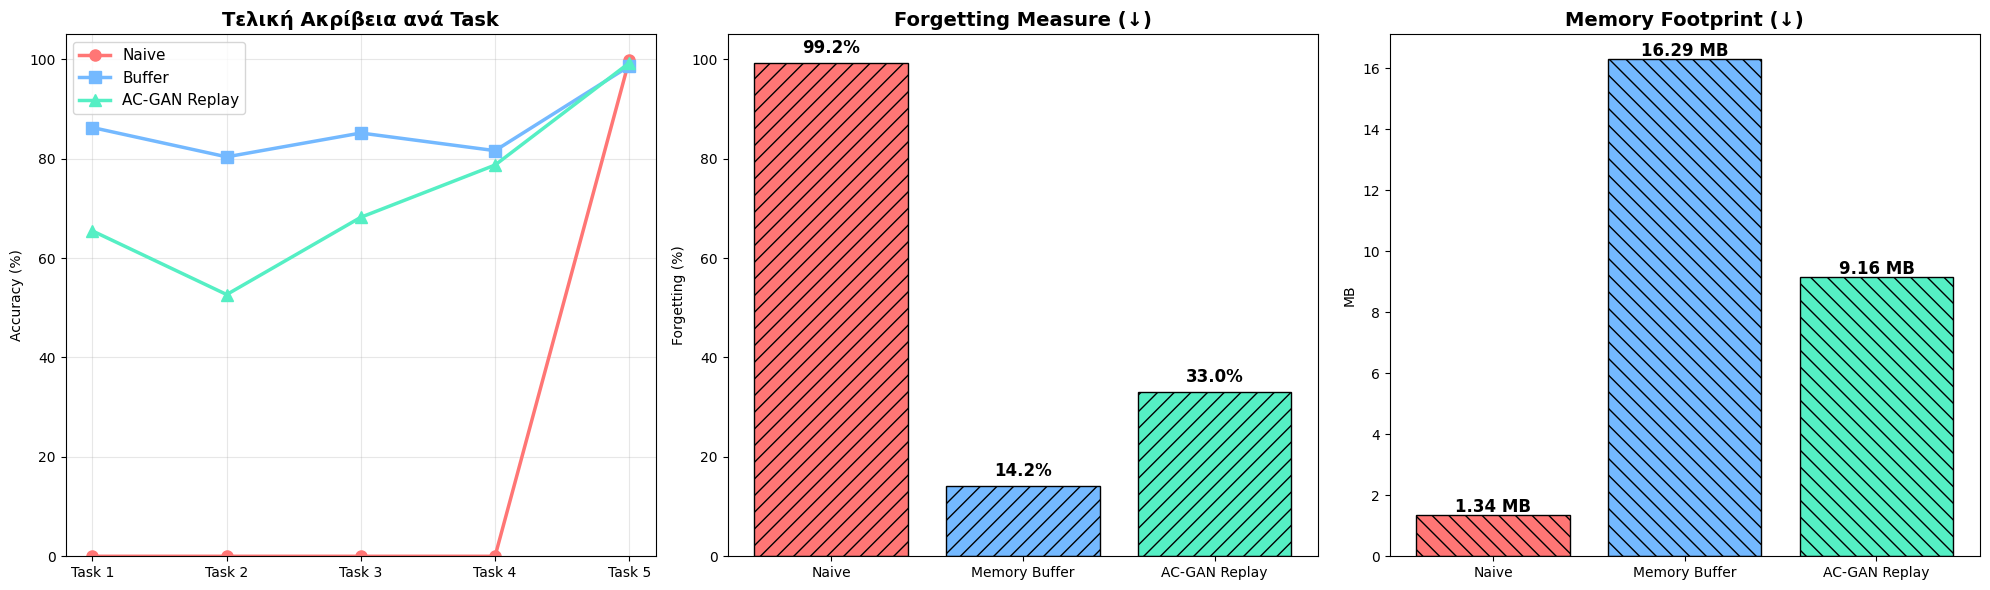

In [ ]:
def pad_accuracies(acc_matrix):
    padded = []
    for row in acc_matrix:
        padded_row = list(row) + [np.nan] * (5 - len(row))
        padded.append(padded_row)
    return padded

f_naive = pad_accuracies(naive_acc_matrix)[-1]
f_buffer = pad_accuracies(buffer_acc_matrix)[-1]
f_gr = pad_accuracies(gr_acc_matrix)[-1]

forg_naive = calculate_forgetting(pad_accuracies(naive_acc_matrix))
forg_buffer = calculate_forgetting(pad_accuracies(buffer_acc_matrix))
forg_gr = calculate_forgetting(pad_accuracies(gr_acc_matrix))

cls_mb = (sum(p.numel() for p in StrongClassifier().parameters()) * 4) / (1024 ** 2)
mem_naive = cls_mb
mem_buffer = cls_mb + ((5000 * 28 * 28 * 4) / (1024 ** 2)) # 5 tasks * 1000 images
mem_gr = cls_mb + ((sum(p.numel() for p in ACGenerator().parameters()) * 4) / (1024 ** 2))

# --- PLOTS ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
methods = ['Naive', 'Memory Buffer', 'AC-GAN Replay']
colors = ['#ff7675', '#74b9ff', '#55efc4']

# 1. Line Plot
x_labels = ['Task 1', 'Task 2', 'Task 3', 'Task 4', 'Task 5']
axes[0].plot(x_labels, f_naive, marker='o', lw=2.5, ms=8, color=colors[0], label='Naive')
axes[0].plot(x_labels, f_buffer, marker='s', lw=2.5, ms=8, color=colors[1], label='Buffer')
axes[0].plot(x_labels, f_gr, marker='^', lw=2.5, ms=8, color=colors[2], label='AC-GAN Replay')
axes[0].set_title('Τελική Ακρίβεια ανά Task', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 105)
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=11)

# 2. Bar Plot (Forgetting)
f_vals = [forg_naive, forg_buffer, forg_gr]
axes[1].bar(methods, f_vals, color=colors, edgecolor='black', hatch='//')
axes[1].set_title('Forgetting Measure (↓)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Forgetting (%)'); axes[1].set_ylim(0, 105)
for i, v in enumerate(f_vals): axes[1].text(i, v+2, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=12)

# 3. Bar Plot (Memory)
m_vals = [mem_naive, mem_buffer, mem_gr]
axes[2].bar(methods, m_vals, color=colors, edgecolor='black', hatch='\\\\')
axes[2].set_title('Memory Footprint (↓)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('MB')
for i, v in enumerate(m_vals): axes[2].text(i, v+0.1, f"{v:.2f} MB", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout(); plt.show()